# Chunk Compute 5-Day Pipeline Benchmark (Custom Strategies, Median-5)

This notebook will:
1. Re-store `DBZH` into Stage-1 zarr using 4 custom chunking strategies.
2. Run Stage-2 pipeline (`VIL + TOP18 + TOP45`) on full 5-day window.
3. Repeat each strategy 5 times and export median/mean summaries and decision table.


## 1) User Settings


In [ ]:
from __future__ import annotations

import gc
import html
import math
import re
import threading
import time
from contextlib import contextmanager, nullcontext
from pathlib import Path

import dask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import psutil
except Exception:
    psutil = None
import resource
import xarray as xr

try:
    from dask.distributed import Client, LocalCluster, get_client, performance_report
except Exception:
    Client = None
    LocalCluster = None
    get_client = None
    performance_report = None

PROJECT_DIR = Path('/home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project')
SOURCE_ZARR = PROJECT_DIR / 'radar_taiwan_2024_with_derived.zarr'

EXPERIMENT_ROOT = PROJECT_DIR / 'benchmark_outputs' / 'chunk_compute_5day_all_products_custom_strategies_median5'
STAGE1_OUTDIR = EXPERIMENT_ROOT / 'stage1_dbzh_stores'
RESULTS_OUTDIR = EXPERIMENT_ROOT / 'results'
PLOT_OUTDIR = EXPERIMENT_ROOT / 'plots'
STAGE2_REPORT_OUTDIR = EXPERIMENT_ROOT / 'stage2_reports'

BENCHMARK_START = '2024-01-01'
BENCHMARK_END = '2024-01-05 23:59:59'
N_REPEATS = 5
MEMORY_SAMPLE_INTERVAL_SEC = 0.05
OVERWRITE_STAGE1 = True

# Dask worker settings (can be tuned)
USE_LOCAL_CLUSTER = True
N_WORKERS = 4
THREADS_PER_WORKER = 1
DASK_DASHBOARD_ADDRESS = ':8787'
DASK_MEMORY_LIMIT = None  # e.g. '8GB'

STRATEGIES = [
    ('S1', {'time': 1, 'alt': 21, 'lat': 561, 'lon': 441}),
    ('S2', {'time': 6, 'alt': 21, 'lat': 561, 'lon': 441}),
    ('S3', {'time': 15, 'alt': 21, 'lat': 128, 'lon': 128}),
    ('S4', {'time': 90, 'alt': 21, 'lat': 128, 'lon': 128}),
]

for p in [EXPERIMENT_ROOT, STAGE1_OUTDIR, RESULTS_OUTDIR, PLOT_OUTDIR, STAGE2_REPORT_OUTDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('SOURCE_ZARR:', SOURCE_ZARR)
print('EXPERIMENT_ROOT:', EXPERIMENT_ROOT)
print('BENCHMARK WINDOW:', BENCHMARK_START, '->', BENCHMARK_END)
print('N_REPEATS:', N_REPEATS)
print('performance_report available:', performance_report is not None)

cluster = None
client = None
if Client is not None:
    try:
        client = get_client() if get_client is not None else None
        if client is not None:
            print('Using existing global Dask client')
    except Exception:
        client = None

if USE_LOCAL_CLUSTER and client is None and LocalCluster is not None and Client is not None:
    cluster_kwargs = {
        'n_workers': N_WORKERS,
        'threads_per_worker': THREADS_PER_WORKER,
        'dashboard_address': DASK_DASHBOARD_ADDRESS,
    }
    if DASK_MEMORY_LIMIT is not None:
        cluster_kwargs['memory_limit'] = DASK_MEMORY_LIMIT
    cluster = LocalCluster(**cluster_kwargs)
    client = Client(cluster)
    print('Started LocalCluster with settings:', cluster_kwargs)
elif client is None:
    print('No Dask client active. Computation still works; performance_report will be skipped.')




SOURCE_ZARR: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/radar_taiwan_2024_with_derived.zarr
EXPERIMENT_ROOT: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5
BENCHMARK WINDOW: 2024-01-01 -> 2024-01-05 23:59:59
N_REPEATS: 5
performance_report available: True
Started LocalCluster with settings: {'n_workers': 4, 'threads_per_worker': 1, 'dashboard_address': ':8787'}


2026-04-22 16:40:12,027 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 72a89d166f3a4a862333e384963b9610 initialized by task ('rechunk-merge-rechunk-transfer-d60dabaeb5fe418f0412c5b2532527ea', 9, 0, 0, 0, 28, 0, 0, 0) executed on worker tcp://127.0.0.1:36695
2026-04-22 16:40:12,263 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 2a156a8fbb00c6d2792f83d034ccbd4d initialized by task ('rechunk-merge-rechunk-transfer-d60dabaeb5fe418f0412c5b2532527ea', 8, 0, 0, 0, 25, 0, 0, 0) executed on worker tcp://127.0.0.1:44509
2026-04-22 16:40:12,567 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cfe5ee762f3a664a05689a0a5e8deb53 initialized by task ('rechunk-merge-rechunk-transfer-d60dabaeb5fe418f0412c5b2532527ea', 7, 0, 0, 0, 22, 0, 0, 0) executed on worker tcp://127.0.0.1:34287
2026-04-22 16:40:13,032 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 43c2a132f948d4f77761094f0ead8467 initialized by task ('rechunk-merge-rechunk-transfer-d60dabaeb5fe418f0

## 2) Helper Functions


In [2]:
if psutil is not None:
    PROCESS = psutil.Process()
else:
    PROCESS = None

def has_active_dask_client() -> bool:
    if get_client is None:
        return False
    try:
        _ = get_client()
        return True
    except Exception:
        return False

def rss_gb() -> float:
    if PROCESS is not None:
        return PROCESS.memory_info().rss / 1024**3
    # ru_maxrss: Linux in KB, macOS in bytes.
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    if rss > 10**10:
        return rss / 1024**3
    return (rss * 1024) / 1024**3

@contextmanager
def timer():
    t0 = time.perf_counter()
    yield lambda: time.perf_counter() - t0

def chunk_bytes_from_da(da: xr.DataArray) -> float:
    if da.chunks is None:
        return float('nan')
    itemsize = np.dtype(da.dtype).itemsize
    first = [c[0] for c in da.chunks]
    n = int(np.prod(first))
    return n * itemsize

def bytes_to_mb(nbytes: float) -> float:
    return float(nbytes) / (1024**2)

def count_chunks(da: xr.DataArray) -> int:
    if da.chunks is None:
        return 1
    total = 1
    for axis_chunks in da.chunks:
        total *= len(axis_chunks)
    return int(total)

def compute_with_peak_memory(compute_func, sample_interval_sec=MEMORY_SAMPLE_INTERVAL_SEC):
    gc.collect()
    mem_before = rss_gb()
    peak = {'rss_gb': mem_before}
    running = {'flag': True}

    def monitor():
        while running['flag']:
            peak['rss_gb'] = max(peak['rss_gb'], rss_gb())
            time.sleep(sample_interval_sec)

    t = threading.Thread(target=monitor, daemon=True)
    t.start()
    try:
        with timer() as get_elapsed:
            result = compute_func()
        elapsed_sec = get_elapsed()
    finally:
        running['flag'] = False
        t.join()

    mem_after = rss_gb()
    return {
        'elapsed_sec': elapsed_sec,
        'mem_before_gb': mem_before,
        'mem_after_gb': mem_after,
        'mem_delta_gb': mem_after - mem_before,
        'mem_peak_gb': peak['rss_gb'],
        'mem_peak_delta_gb': peak['rss_gb'] - mem_before,
        'result': result,
    }

def _parse_time_to_seconds(text: str) -> float:
    text = str(text).strip()

    m = re.match(r'([0-9.]+)\s*ms$', text)
    if m:
        return float(m.group(1)) / 1000.0

    m = re.match(r'([0-9.]+)\s*s$', text)
    if m:
        return float(m.group(1))

    # keep HW3 style and add compact dask format support (e.g., 18m 29s)
    m = re.match(r'([0-9.]+)\s*min\s*([0-9.]+)\s*s$', text)
    if m:
        return float(m.group(1)) * 60.0 + float(m.group(2))

    m = re.match(r'([0-9.]+)\s*m\s*([0-9.]+)\s*s$', text)
    if m:
        return float(m.group(1)) * 60.0 + float(m.group(2))

    return np.nan

def parse_dask_report_summary(html_path: str | Path) -> dict:
    html_path = Path(html_path)
    out = {
        'report_duration_s': np.nan,
        'n_tasks': np.nan,
        'compute_time_s': np.nan,
        'transfer_time_s': np.nan,
    }
    if not html_path.exists():
        return out

    text = html_path.read_text(encoding='utf-8', errors='ignore')
    # Dask report often embeds escaped HTML like &lt;li&gt;...&lt;/li&gt;
    text = html.unescape(text)

    m = re.search(r'Duration:\s*([^<\n]+)', text, flags=re.IGNORECASE)
    if m:
        out['report_duration_s'] = _parse_time_to_seconds(m.group(1).strip())

    m = re.search(r'number of tasks:\s*([0-9]+)', text, flags=re.IGNORECASE)
    if m:
        out['n_tasks'] = int(m.group(1))

    m = re.search(r'compute time:\s*([^<\n]+)', text, flags=re.IGNORECASE)
    if m:
        out['compute_time_s'] = _parse_time_to_seconds(m.group(1).strip())

    m = re.search(r'transfer time:\s*([^<\n]+)', text, flags=re.IGNORECASE)
    if m:
        out['transfer_time_s'] = _parse_time_to_seconds(m.group(1).strip())

    return out





## 3) Scientific Functions (VIL / TOP18 / TOP45)


In [3]:
ZLEVELS_QPE = np.array([
    1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000,
    6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000,
    14000, 15000, 16000, 17000,
], dtype=np.float32)

THRESHOLDS = {'TOP18': 18.0, 'TOP45': 45.0}
VIL_mFac = 3.44e-3
VIL_DBZ_FLOOR = 0.0

def ensure_alt_coordinate(dbzh: xr.DataArray) -> xr.DataArray:
    if 'alt' not in dbzh.dims:
        raise ValueError('DBZH must include alt dimension')
    if 'alt' not in dbzh.coords or len(dbzh['alt']) != len(ZLEVELS_QPE):
        dbzh = dbzh.assign_coords(alt=ZLEVELS_QPE)
    return dbzh

def compute_vil_xarray(dbzh: xr.DataArray, z_levels_m: np.ndarray = ZLEVELS_QPE, mfac: float = VIL_mFac, dbz_floor: float = VIL_DBZ_FLOOR) -> xr.DataArray:
    dbzh = ensure_alt_coordinate(dbzh)
    if dbzh.sizes['alt'] != len(z_levels_m):
        raise ValueError('DBZH alt size mismatch')

    delta_h = np.diff(z_levels_m, prepend=z_levels_m[0]).astype(np.float32)
    delta_h[0] = delta_h[1]
    delta_h_km = xr.DataArray(delta_h / 1000.0, dims=['alt'], coords={'alt': dbzh['alt']})

    dbzh_valid = xr.where(dbzh > dbz_floor, dbzh, np.nan)
    Z = 10.0 ** (0.1 * dbzh_valid)
    vil_layer = xr.where(np.isfinite(dbzh_valid), mfac * (Z ** (4.0 / 7.0)) * delta_h_km, 0.0)
    vil = vil_layer.sum(dim='alt', skipna=True)
    vil.name = 'VIL'
    vil.attrs['units'] = 'kg m-2'
    return vil

def compute_echotop_xarray(dbzh: xr.DataArray, threshold: float, z_levels_m: np.ndarray = ZLEVELS_QPE, output_name: str = 'ECHOTOP') -> xr.DataArray:
    dbzh = ensure_alt_coordinate(dbzh)
    alt_vals = np.asarray(z_levels_m, dtype=np.float32)
    nalt = len(alt_vals)
    if dbzh.sizes['alt'] != nalt:
        raise ValueError('DBZH alt size mismatch')

    template = dbzh.isel(alt=0, drop=True)
    echotop = xr.zeros_like(template, dtype=np.float32)
    top_mask = dbzh.isel(alt=-1) >= threshold
    echotop = xr.where(top_mask, alt_vals[-1], echotop)

    for i in range(nalt - 2, -1, -1):
        lower = dbzh.isel(alt=i)
        upper = dbzh.isel(alt=i + 1)
        h_lower = np.float32(alt_vals[i])
        h_upper = np.float32(alt_vals[i + 1])
        cross_mask = (lower >= threshold) & (upper < threshold) & (echotop == 0)
        denom = upper - lower
        interp = h_lower + (h_upper - h_lower) * (threshold - lower) / xr.where(denom == 0, np.nan, denom)
        interp = xr.where(np.isfinite(interp), interp, h_lower)
        echotop = xr.where(cross_mask, interp.astype(np.float32), echotop)

    echotop.name = output_name
    echotop.attrs['units'] = 'm'
    return echotop

def compute_top18(dbzh: xr.DataArray) -> xr.DataArray:
    return compute_echotop_xarray(dbzh=dbzh, threshold=THRESHOLDS['TOP18'], output_name='TOP18')

def compute_top45(dbzh: xr.DataArray) -> xr.DataArray:
    return compute_echotop_xarray(dbzh=dbzh, threshold=THRESHOLDS['TOP45'], output_name='TOP45')

def compute_vil(dbzh: xr.DataArray) -> xr.DataArray:
    return compute_vil_xarray(dbzh=dbzh)

def compute_all_products(dbzh: xr.DataArray):
    vil = compute_vil(dbzh)
    top18 = compute_top18(dbzh)
    top45 = compute_top45(dbzh)
    return vil, top18, top45


## 4) Stage-1: Re-store DBZH with Custom Strategies


In [4]:
if not SOURCE_ZARR.exists():
    raise FileNotFoundError(SOURCE_ZARR)

src = xr.open_zarr(SOURCE_ZARR, consolidated=True)
dbzh_src = src['DBZH'].sel(time=slice(BENCHMARK_START, BENCHMARK_END))
if dbzh_src.sizes.get('time', 0) == 0:
    raise RuntimeError('No DBZH data in selected 5-day window')

stage1_rows = []

for store_key, chunk_spec in STRATEGIES:
    out_path = STAGE1_OUTDIR / store_key
    if out_path.exists() and OVERWRITE_STAGE1:
        import shutil
        shutil.rmtree(out_path)

    print(f'[Stage-1] writing {store_key} with {chunk_spec} ...')
    dbzh = dbzh_src.chunk(chunk_spec)
    chunk_mb = bytes_to_mb(chunk_bytes_from_da(dbzh))
    nchunks = count_chunks(dbzh)

    def write_store():
        ds_out = dbzh.to_dataset(name='DBZH')

        # 清掉來源繼承的 chunks encoding，避免和目前 dask chunks 衝突
        ds_out["DBZH"].encoding = {}

        # 用目前 dask chunk 當作 zarr chunk
        zarr_chunks = tuple(int(ax[0]) for ax in dbzh.chunks)

        ds_out.to_zarr(
            out_path,
            mode="w",
            consolidated=True,
            encoding={"DBZH": {"chunks": zarr_chunks}},
            align_chunks=True,
        )
        return True


    m = compute_with_peak_memory(write_store)
    _ = m.pop('result')
    size_gb = sum(pp.stat().st_size for pp in out_path.rglob('*') if pp.is_file()) / (1024**3)
    stage1_rows.append({
        'store_key': store_key,
        'chunk_spec': str(chunk_spec),
        'success': True,
        'elapsed_sec': m['elapsed_sec'],
        'mem_before_gb': m['mem_before_gb'],
        'mem_after_gb': m['mem_after_gb'],
        'mem_delta_gb': m['mem_delta_gb'],
        'mem_peak_delta_gb': m['mem_peak_delta_gb'],
        'chunk_mb': chunk_mb,
        'nchunks': nchunks,
        'store_path_abs': str(out_path.resolve()),
        'store_size_gb': size_gb,
    })

stage1_df = pd.DataFrame(stage1_rows).sort_values('store_key')
stage1_csv = RESULTS_OUTDIR / 'stage1_storage_results_custom_5day.csv'
stage1_df.to_csv(stage1_csv, index=False)
print('Saved:', stage1_csv)
stage1_df


[Stage-1] writing S1 with {'time': 1, 'alt': 21, 'lat': 561, 'lon': 441} ...


/home/NAS/homes/pinghung-10018/Course_data/Isungche/W1_hands-on/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[Stage-1] writing S2 with {'time': 6, 'alt': 21, 'lat': 561, 'lon': 441} ...


/home/NAS/homes/pinghung-10018/Course_data/Isungche/W1_hands-on/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[Stage-1] writing S3 with {'time': 15, 'alt': 21, 'lat': 128, 'lon': 128} ...


/home/NAS/homes/pinghung-10018/Course_data/Isungche/W1_hands-on/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[Stage-1] writing S4 with {'time': 90, 'alt': 21, 'lat': 128, 'lon': 128} ...


/home/NAS/homes/pinghung-10018/Course_data/Isungche/W1_hands-on/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/results/stage1_storage_results_custom_5day.csv


,store_key,chunk_spec,success,elapsed_sec,mem_before_gb,mem_after_gb,mem_delta_gb,mem_peak_delta_gb,chunk_mb,nchunks,store_path_abs,store_size_gb
0,S1,"{'time': 1, 'alt': 21, 'lat': 561, 'lon': 441}",True,10.501411,0.254238,0.272190,0.017952,0.017628,19.818958,717,/home/NAS/homes/pinghung-10018/Course_data/Isu...,0.040889
1,S2,"{'time': 6, 'alt': 21, 'lat': 561, 'lon': 441}",True,8.553802,0.272190,0.280632,0.008442,0.008442,118.913750,120,/home/NAS/homes/pinghung-10018/Course_data/Isu...,0.040861
2,S3,"{'time': 15, 'alt': 21, 'lat': 128, 'lon': 128}",True,20.444220,0.280632,0.293980,0.013348,0.013344,19.687500,960,/home/NAS/homes/pinghung-10018/Course_data/Isu...,0.045980
3,S4,"{'time': 90, 'alt': 21, 'lat': 128, 'lon': 128}",True,17.967884,0.293980,0.294479,0.000500,0.002769,118.125000,160,/home/NAS/homes/pinghung-10018/Course_data/Isu...,0.046169


## 5) Stage-1 Plots


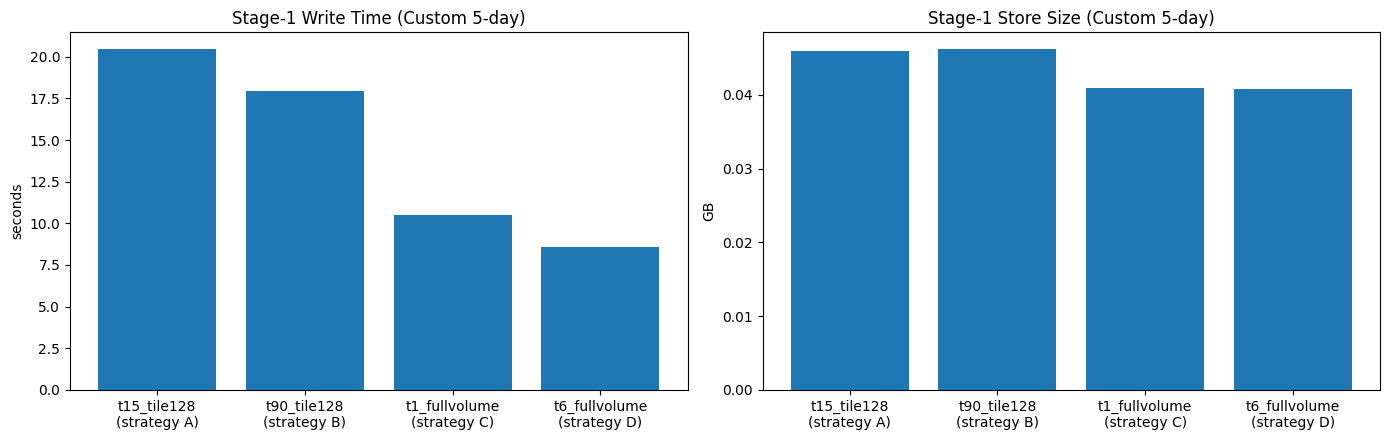

Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/plots/stage1_storage_cost_custom_5day.png


In [10]:
if len(stage1_df) > 0:
    strategy_order = ['S3', 'S4', 'S1', 'S2']
    strategy_label_map = {
        'S3': 't15_tile128\n(strategy A)',
        'S4': 't90_tile128\n(strategy B)',
        'S1': 't1_fullvolume\n(strategy C)',
        'S2': 't6_fullvolume\n(strategy D)',
    }

    plot_df = stage1_df.copy()
    plot_df['strategy_order'] = plot_df['store_key'].map({k: i for i, k in enumerate(strategy_order)})
    plot_df['strategy'] = plot_df['store_key'].map(strategy_label_map).fillna(plot_df['store_key'])
    plot_df = plot_df.sort_values('strategy_order').reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].bar(plot_df['strategy'], plot_df['elapsed_sec'])
    axes[0].set_title('Stage-1 Write Time (Custom 5-day)')
    axes[0].set_ylabel('seconds')

    axes[1].bar(plot_df['strategy'], plot_df['store_size_gb'])
    axes[1].set_title('Stage-1 Store Size (Custom 5-day)')
    axes[1].set_ylabel('GB')

    plt.tight_layout()
    p = PLOT_OUTDIR / 'stage1_storage_cost_custom_5day.png'
    plt.savefig(p, dpi=150)
    plt.show()
    print('Saved:', p)



## 6) Stage-2: Pipeline Benchmark on Full 5 Days (Repeat=5)


In [6]:
def benchmark_pipeline_one_repeat(store_key: str, store_path: str, repeat_index: int):
    ds_store = xr.open_zarr(store_path, consolidated=True)
    dbzh = ds_store['DBZH'].sel(time=slice(BENCHMARK_START, BENCHMARK_END))
    if dbzh.sizes.get('time', 0) == 0:
        raise RuntimeError(f'No data in benchmark window for {store_key}')

    report_path = STAGE2_REPORT_OUTDIR / f'report_stage2_{store_key}_r{repeat_index}.html'

    def run_pipeline():
        use_report = performance_report is not None and has_active_dask_client()
        report_cm = performance_report(filename=str(report_path)) if use_report else nullcontext()
        with report_cm:
            vil, top18, top45 = compute_all_products(dbzh)
            return dask.compute(vil, top18, top45)

    m = compute_with_peak_memory(run_pipeline)
    _ = m.pop('result')
    report_summary = parse_dask_report_summary(report_path)

    return {
        'store_key': store_key,
        'repeat_index': repeat_index,
        'workload': 'ALL_VIL_TOP18_TOP45_5DAY',
        'n_time': int(dbzh.sizes['time']),
        'report_path': str(report_path),
        **report_summary,
        **m,
    }

repeat_rows = []
for _, row in stage1_df.iterrows():
    for r in range(1, N_REPEATS + 1):
        print(f'[Stage-2] {row.store_key} repeat {r}/{N_REPEATS}')
        repeat_rows.append(benchmark_pipeline_one_repeat(row.store_key, row.store_path_abs, r))

pipeline_runs_df = pd.DataFrame(repeat_rows).sort_values(['store_key', 'repeat_index'])
runs_csv = RESULTS_OUTDIR / 'stage2_pipeline_all_products_5day_repeat_runs.csv'
pipeline_runs_df.to_csv(runs_csv, index=False)
print('Saved:', runs_csv)
pipeline_runs_df.head()



[Stage-2] S1 repeat 1/5
[Stage-2] S1 repeat 2/5
[Stage-2] S1 repeat 3/5
[Stage-2] S1 repeat 4/5
[Stage-2] S1 repeat 5/5
[Stage-2] S2 repeat 1/5
[Stage-2] S2 repeat 2/5
[Stage-2] S2 repeat 3/5
[Stage-2] S2 repeat 4/5
[Stage-2] S2 repeat 5/5
[Stage-2] S3 repeat 1/5
[Stage-2] S3 repeat 2/5
[Stage-2] S3 repeat 3/5
[Stage-2] S3 repeat 4/5
[Stage-2] S3 repeat 5/5
[Stage-2] S4 repeat 1/5
[Stage-2] S4 repeat 2/5
[Stage-2] S4 repeat 3/5
[Stage-2] S4 repeat 4/5
[Stage-2] S4 repeat 5/5
Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/results/stage2_pipeline_all_products_5day_repeat_runs.csv


,store_key,repeat_index,workload,n_time,report_path,report_duration_s,n_tasks,compute_time_s,transfer_time_s,elapsed_sec,mem_before_gb,mem_after_gb,mem_delta_gb,mem_peak_gb,mem_peak_delta_gb
0,S1,1,ALL_VIL_TOP18_TOP45_5DAY,717,/home/NAS/homes/pinghung-10018/Course_data/Isu...,94.13,33704,290.71,22.27,95.697341,0.303818,2.537193,2.233376,4.512791,4.208973
1,S1,2,ALL_VIL_TOP18_TOP45_5DAY,717,/home/NAS/homes/pinghung-10018/Course_data/Isu...,93.04,33704,288.27,17.47,93.983876,0.565533,2.574745,2.009212,5.233677,4.668144
2,S1,3,ALL_VIL_TOP18_TOP45_5DAY,717,/home/NAS/homes/pinghung-10018/Course_data/Isu...,89.08,33704,272.98,17.07,90.031360,0.609985,2.642376,2.032391,4.612713,4.002728
3,S1,4,ALL_VIL_TOP18_TOP45_5DAY,717,/home/NAS/homes/pinghung-10018/Course_data/Isu...,91.37,33704,280.62,17.03,92.517671,0.660145,2.619915,1.959770,4.622288,3.962143
4,S1,5,ALL_VIL_TOP18_TOP45_5DAY,717,/home/NAS/homes/pinghung-10018/Course_data/Isu...,90.09,33704,281.59,9.52,91.192703,0.655968,2.653687,1.997719,4.617023,3.961056


## 7) Aggregate (Median-5 / Mean-5)


In [7]:
agg = pipeline_runs_df.groupby('store_key').agg(
    n_success=('store_key', 'size'),
    n_time=('n_time', 'max'),
    elapsed_sec_median=('elapsed_sec', 'median'),
    elapsed_sec_mean=('elapsed_sec', 'mean'),
    elapsed_sec_std=('elapsed_sec', 'std'),
    mem_peak_delta_gb_median=('mem_peak_delta_gb', 'median'),
    mem_peak_delta_gb_mean=('mem_peak_delta_gb', 'mean'),
    mem_delta_gb_median=('mem_delta_gb', 'median'),
    report_duration_s_median=('report_duration_s', 'median'),
    n_tasks_median=('n_tasks', 'median'),
    compute_time_s_median=('compute_time_s', 'median'),
    transfer_time_s_median=('transfer_time_s', 'median'),
).reset_index()

pipeline_median_df = agg.merge(
    stage1_df[['store_key', 'chunk_spec', 'chunk_mb', 'nchunks', 'store_size_gb']],
    on='store_key',
    how='left'
)
pipeline_median_df['throughput_mb_s'] = (pipeline_median_df['chunk_mb'] * pipeline_median_df['nchunks']) / pipeline_median_df['elapsed_sec_median']
pipeline_median_df['transfer_time_ms_median'] = pipeline_median_df['transfer_time_s_median'] * 1000.0

strategy_order = ['S3', 'S4', 'S1', 'S2']
strategy_label_map = {
    'S3': 't15_tile128\n(strategy A)',
    'S4': 't90_tile128\n(strategy B)',
    'S1': 't1_fullvolume\n(strategy C)',
    'S2': 't6_fullvolume\n(strategy D)',
}

pipeline_median_df['strategy_order'] = pipeline_median_df['store_key'].map({k: i for i, k in enumerate(strategy_order)})
pipeline_median_df['strategy'] = pipeline_median_df['store_key'].map(strategy_label_map).fillna(pipeline_median_df['store_key'])
pipeline_median_df = pipeline_median_df.sort_values('strategy_order').reset_index(drop=True)

median_csv = RESULTS_OUTDIR / 'stage2_pipeline_all_products_5day_median5.csv'
mean_csv = RESULTS_OUTDIR / 'stage2_pipeline_all_products_5day_mean5.csv'
pipeline_median_df.to_csv(median_csv, index=False)
pipeline_median_df.to_csv(mean_csv, index=False)
print('Saved:', median_csv)
pipeline_median_df




Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/results/stage2_pipeline_all_products_5day_median5.csv


,store_key,n_success,n_time,elapsed_sec_median,elapsed_sec_mean,elapsed_sec_std,mem_peak_delta_gb_median,mem_peak_delta_gb_mean,mem_delta_gb_median,report_duration_s_median,...,compute_time_s_median,transfer_time_s_median,chunk_spec,chunk_mb,nchunks,store_size_gb,throughput_mb_s,transfer_time_ms_median,strategy_order,strategy
0,S3,5,717,99.578566,98.734780,2.472403,4.040615,4.259266,1.975288,97.85,...,288.07,13.28,"{'time': 15, 'alt': 21, 'lat': 128, 'lon': 128}",19.687500,960,0.045980,189.799881,13280.0,0,t15_tile128\n(strategy A)
1,S4,5,717,155.722926,158.659479,8.517122,3.964752,4.089851,1.982239,154.78,...,575.08,97.12,"{'time': 90, 'alt': 21, 'lat': 128, 'lon': 128}",118.125000,160,0.046169,121.369412,97120.0,1,t90_tile128\n(strategy B)
2,S1,5,717,92.517671,92.684590,2.239310,4.002728,4.160609,2.009212,91.37,...,281.59,17.07,"{'time': 1, 'alt': 21, 'lat': 561, 'lon': 441}",19.818958,717,0.040889,153.594367,17070.0,2,t1_fullvolume\n(strategy C)
3,S2,5,717,197.468534,195.715529,14.187807,3.956638,3.953503,1.974243,197.01,...,742.00,102.67,"{'time': 6, 'alt': 21, 'lat': 561, 'lon': 441}",118.913750,120,0.040861,72.262905,102670.0,3,t6_fullvolume\n(strategy D)


## 8) Decision Table


In [8]:
decision_df = pipeline_median_df.copy()
for col in ['elapsed_sec_median', 'store_size_gb', 'mem_peak_delta_gb_median']:
    vmin, vmax = decision_df[col].min(), decision_df[col].max()
    if math.isclose(vmin, vmax):
        decision_df[col + '_norm'] = 0.0
    else:
        decision_df[col + '_norm'] = (decision_df[col] - vmin) / (vmax - vmin)

# weights: compute 0.5, peak memory 0.3, size 0.2
decision_df['score'] = (
    0.5 * decision_df['elapsed_sec_median_norm']
    + 0.3 * decision_df['mem_peak_delta_gb_median_norm']
    + 0.2 * decision_df['store_size_gb_norm']
)
decision_df = decision_df.sort_values('score')

decision_csv = RESULTS_OUTDIR / 'decision_table_pipeline_all_products_5day_median5.csv'
decision_df.to_csv(decision_csv, index=False)
print('Saved:', decision_csv)
decision_df[['store_key', 'chunk_spec', 'elapsed_sec_median', 'throughput_mb_s', 'mem_peak_delta_gb_median', 'store_size_gb', 'score']]


Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/results/decision_table_pipeline_all_products_5day_median5.csv


,store_key,chunk_spec,elapsed_sec_median,throughput_mb_s,mem_peak_delta_gb_median,store_size_gb,score
2,S1,"{'time': 1, 'alt': 21, 'lat': 561, 'lon': 441}",92.517671,153.594367,4.002728,0.040889,0.165737
3,S2,"{'time': 6, 'alt': 21, 'lat': 561, 'lon': 441}",197.468534,72.262905,3.956638,0.040861,0.500000
0,S3,"{'time': 15, 'alt': 21, 'lat': 128, 'lon': 128}",99.578566,189.799881,4.040615,0.045980,0.526527
1,S4,"{'time': 90, 'alt': 21, 'lat': 128, 'lon': 128}",155.722926,121.369412,3.964752,0.046169,0.530104


## 9) Plots


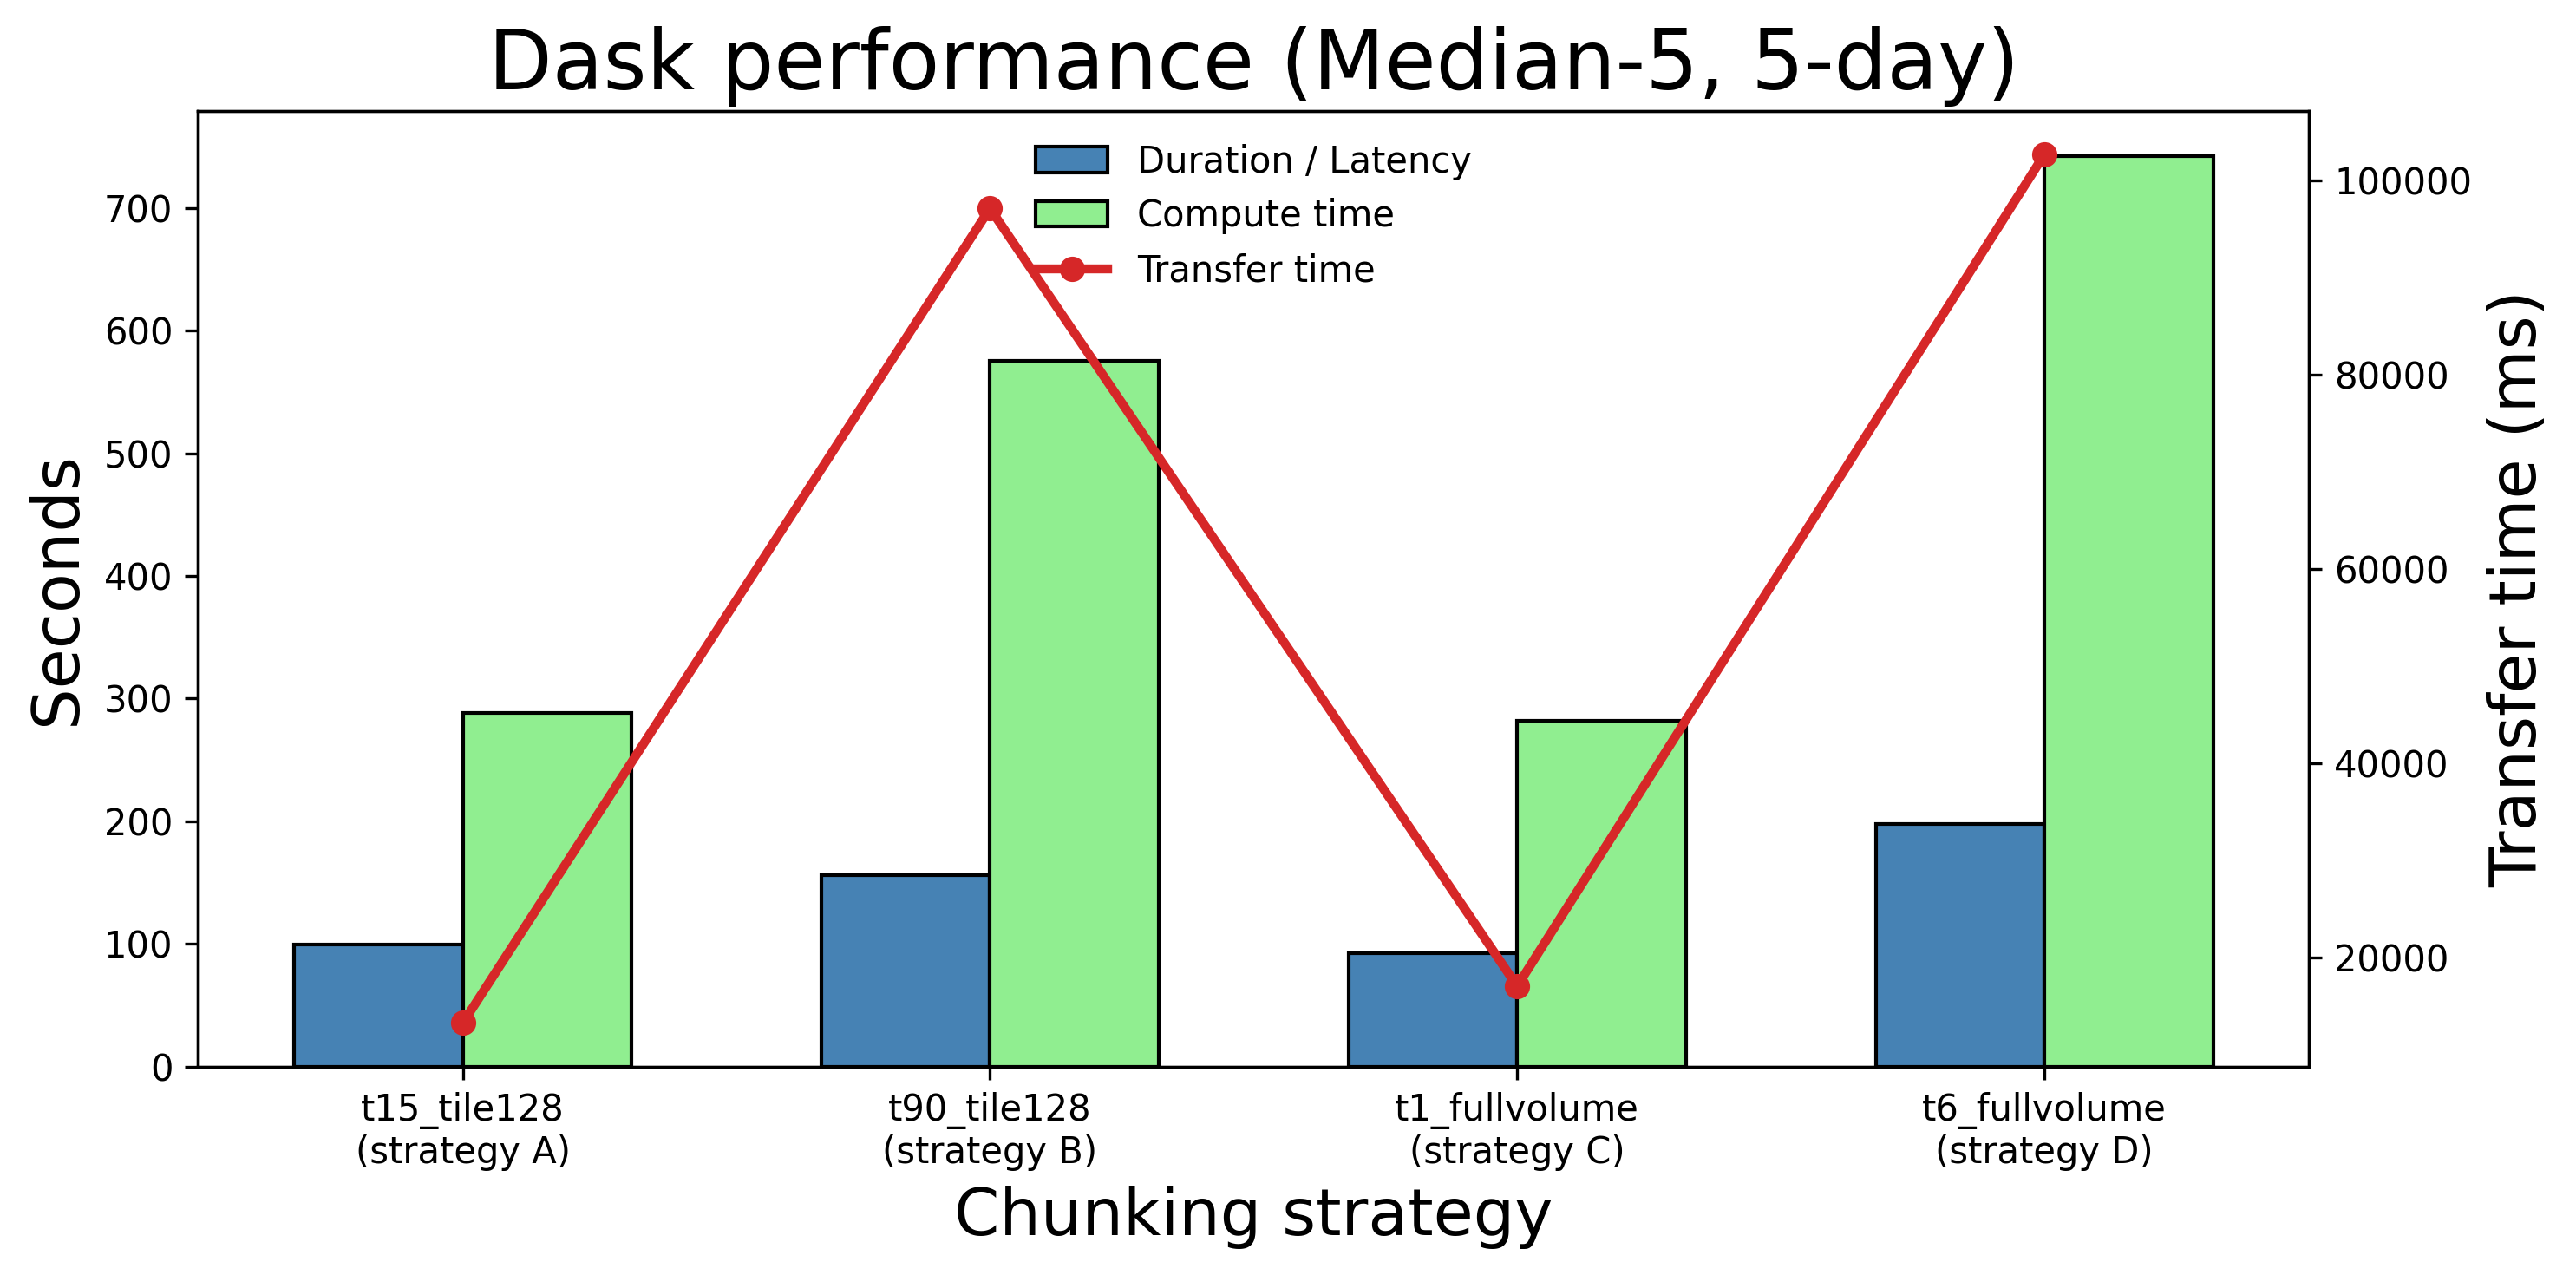

Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/plots/stage2_pipeline_all_products_5day_dask_performance_median5.png


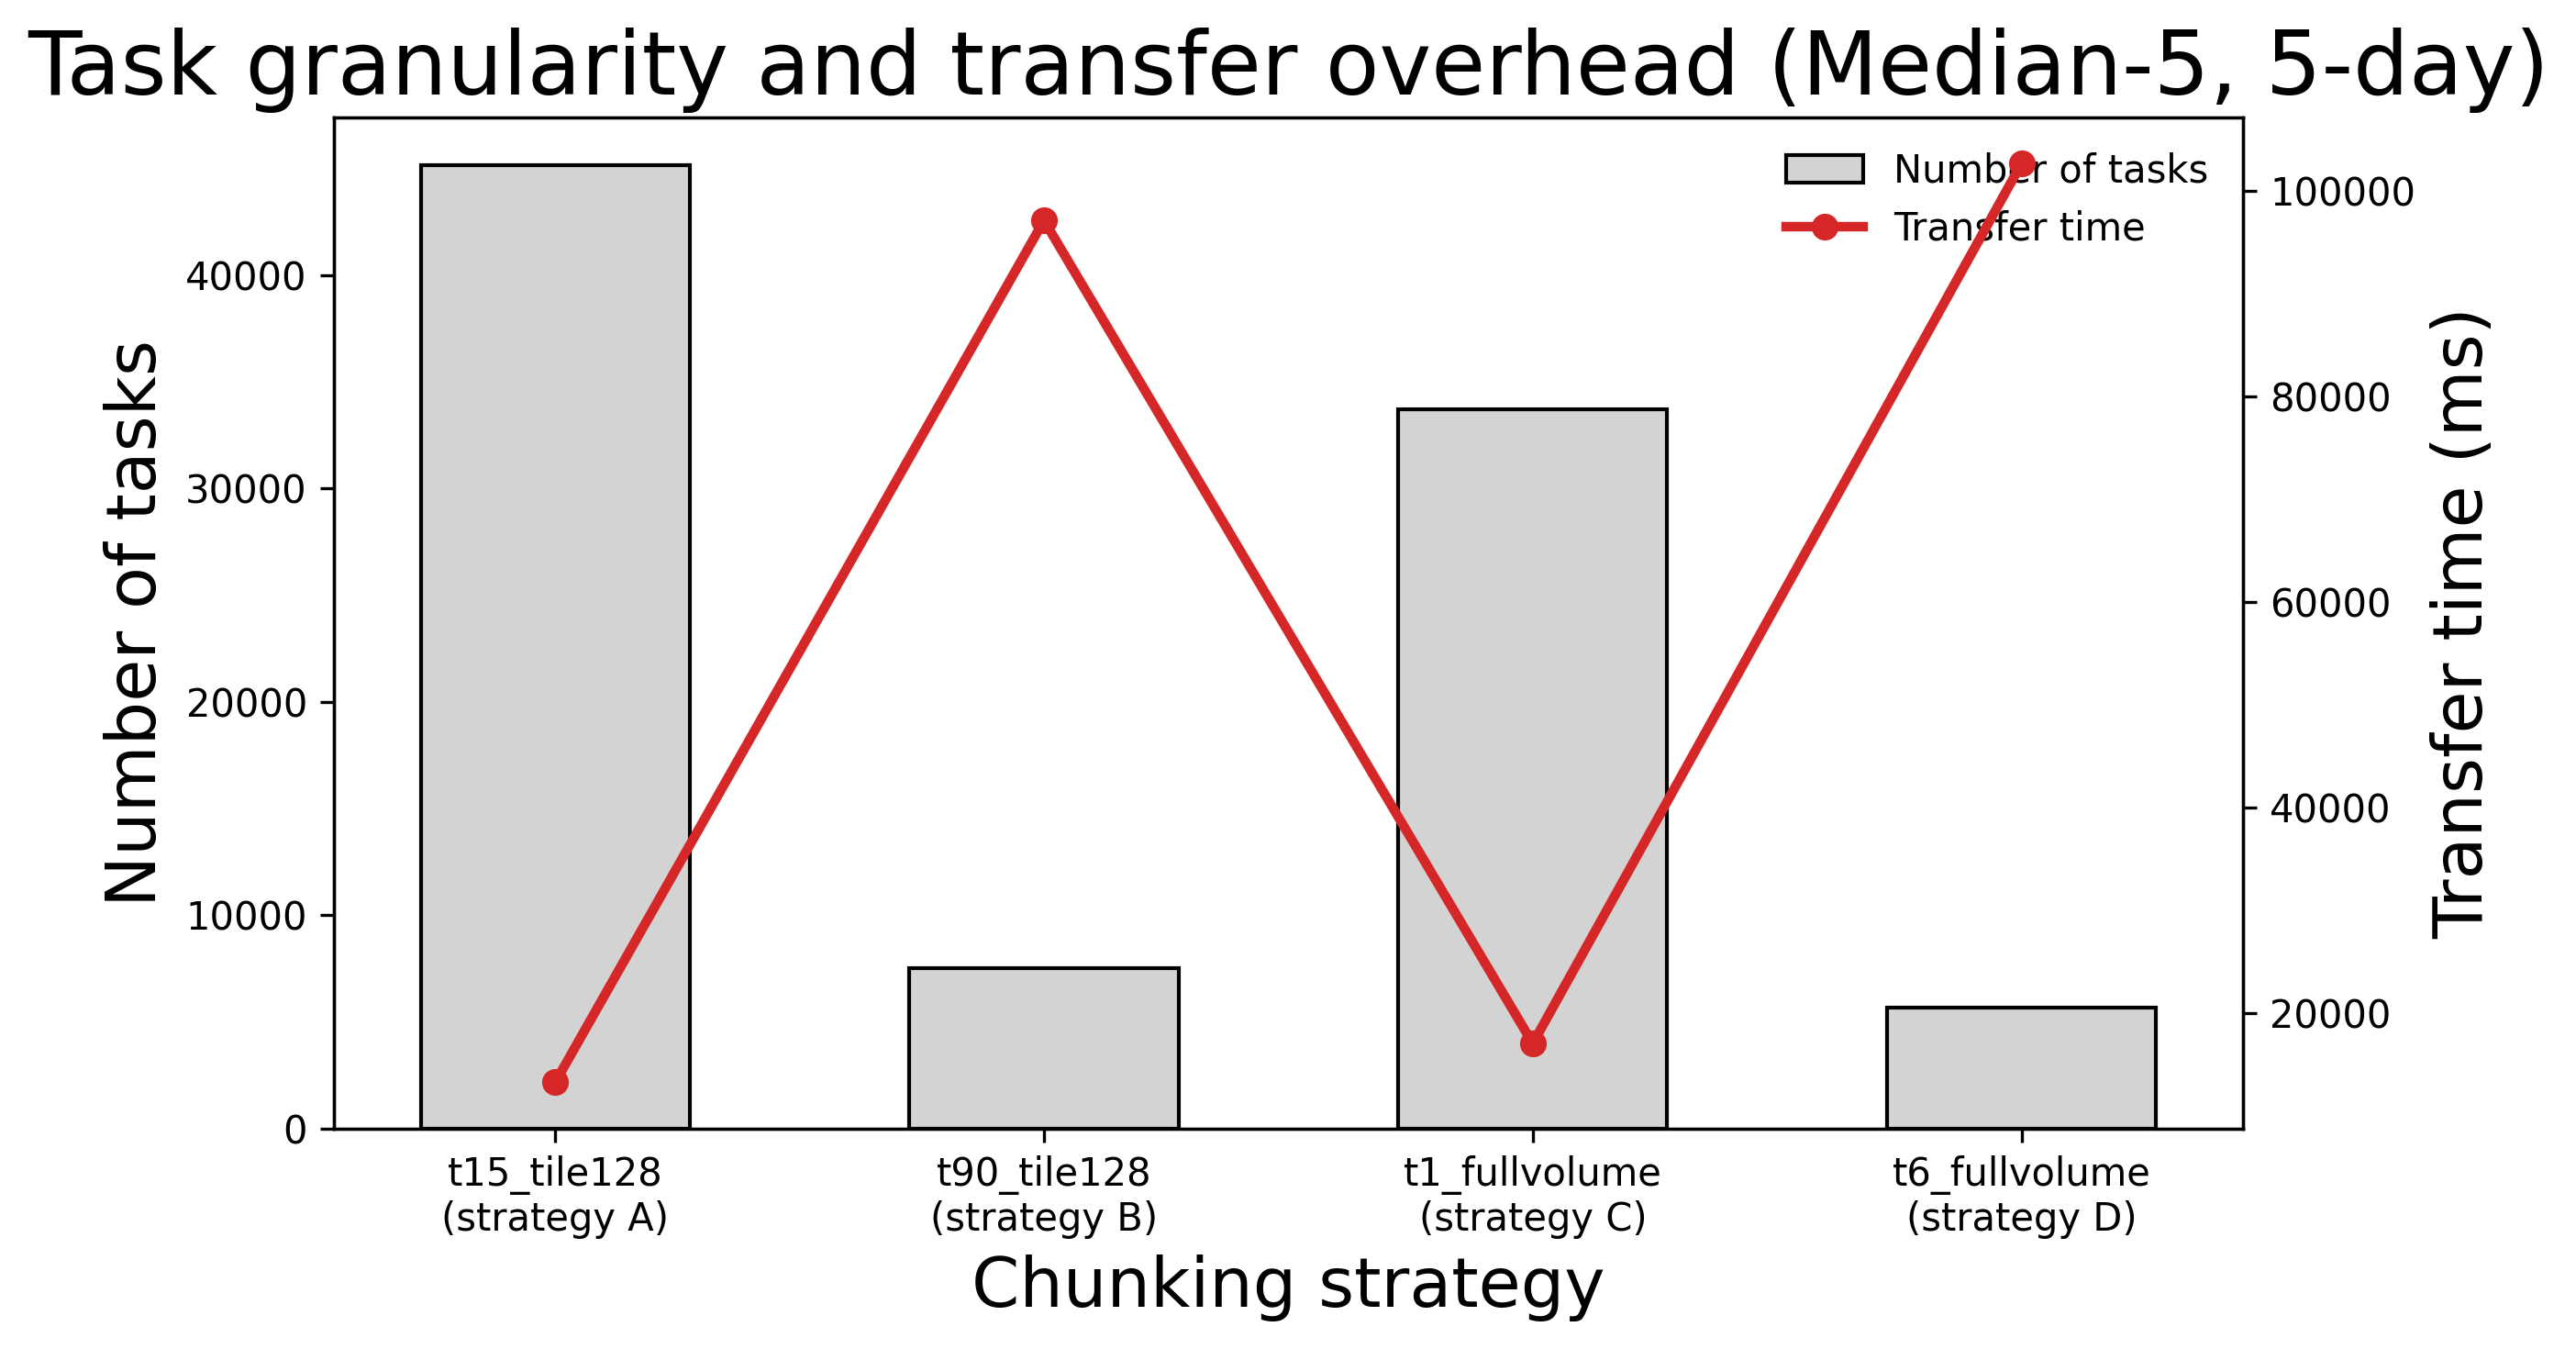

Saved: /home/NAS/homes/pinghung-10018/Course_data/Isungche/Final_project/benchmark_outputs/chunk_compute_5day_all_products_custom_strategies_median5/plots/stage2_pipeline_all_products_5day_task_granularity_median5.png


In [9]:
fontsize = 18
dpi = 300

if len(pipeline_median_df) > 0:
    p = pipeline_median_df.sort_values('strategy_order').copy()

    # Plot 1: Dask performance (Duration / Compute + Transfer)
    x = np.arange(len(p))
    w = 0.32

    fig, ax1 = plt.subplots(figsize=(10, 5), dpi=dpi)

    ax1.bar(
        x - w/2,
        p['elapsed_sec_median'],
        width=w,
        color='steelblue',
        edgecolor='black',
        label='Duration / Latency',
        zorder=1,
    )

    ax1.bar(
        x + w/2,
        p['compute_time_s_median'],
        width=w,
        color='lightgreen',
        edgecolor='black',
        label='Compute time',
        zorder=1,
    )

    ax1.set_xticks(x)
    ax1.set_xticklabels(p['strategy'])
    ax1.set_ylabel('Seconds', fontsize=fontsize)
    ax1.set_xlabel('Chunking strategy', fontsize=fontsize)

    ax2 = ax1.twinx()
    ax2.plot(
        x,
        p['transfer_time_ms_median'],
        marker='o',
        linewidth=2.5,
        color='tab:red',
        label='Transfer time',
        zorder=3,
    )
    ax2.set_ylabel('Transfer time (ms)', fontsize=fontsize)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', frameon=False)

    plt.title('Dask performance (Median-5, 5-day)', fontsize=fontsize+5)
    plt.tight_layout()
    fig_path1 = PLOT_OUTDIR / 'stage2_pipeline_all_products_5day_dask_performance_median5.png'
    plt.savefig(fig_path1, dpi=dpi)
    plt.show()
    print('Saved:', fig_path1)

    # Plot 2: Task granularity + Transfer overhead
    fig, ax1 = plt.subplots(figsize=(9, 5), dpi=dpi)

    ax1.bar(
        x,
        p['n_tasks_median'],
        width=0.55,
        color='lightgray',
        edgecolor='black',
        label='Number of tasks',
        zorder=1,
    )

    ax1.set_xticks(x)
    ax1.set_xticklabels(p['strategy'])
    ax1.set_ylabel('Number of tasks', fontsize=fontsize)
    ax1.set_xlabel('Chunking strategy', fontsize=fontsize)

    ax2 = ax1.twinx()
    ax2.plot(
        x,
        p['transfer_time_ms_median'],
        marker='o',
        linewidth=2.5,
        color='tab:red',
        label='Transfer time',
        zorder=3,
    )
    ax2.set_ylabel('Transfer time (ms)', fontsize=fontsize)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False)

    plt.title('Task granularity and transfer overhead (Median-5, 5-day)', fontsize=fontsize+5)
    plt.tight_layout()
    fig_path2 = PLOT_OUTDIR / 'stage2_pipeline_all_products_5day_task_granularity_median5.png'
    plt.savefig(fig_path2, dpi=dpi)
    plt.show()
    print('Saved:', fig_path2)

